## задача фильтрации


Уравнение неразрывности $ \operatorname{div} \mathbf{u} = 0 \quad \Rightarrow \quad \frac{du}{dx} = 0 $


Закон Дарси $ u = -\frac{1}{\mu(|u|)} \frac{dp}{dx} $

Нелинейная вязкость $ \mu(|u|) = \mu_0 \left( 1 + \frac{1}{|u|} \right) $

Граничные условия $ p(0) = p_1, \qquad p(L) = p_2, \quad p_2 < p_1 $.

---

Итоговое решение

Скорость фильтрации
$
\boxed{
u(x) = u_* = \text{const}
}
$

Давление
$
\boxed{
p(x) = p_1 - \frac{p_1 - p_2}{L}\,x
}
$

In [1]:
import deepxde as dde
import numpy as np
import torch
import matplotlib.pyplot as plt

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [2]:
L = 1.0
p1 = 1.0
p2 = 0.0
mu0 = 1.0
eps = 1e-3

def mu(u):
    return mu0 * (1.0 + 1.0 / (torch.abs(u) + eps))

def pde(x, y):
    """
    y[:,0] = p(x)
    y[:,1] = u(x)
    """
    p = y[:, 0:1]
    u = y[:, 1:2]

    dp_dx = dde.grad.jacobian(y, x, i=0)
    du_dx = dde.grad.jacobian(y, x, i=1)

    # div u = 0
    eq1 = du_dx
    # u + (1/mu) * dp/dx = 0
    eq2 = u + (1.0 / mu(u)) * dp_dx

    return [eq1, eq2]


In [3]:
geom = dde.geometry.Interval(0.0, L)

def boundary_left(x, on_boundary):
    return on_boundary and np.isclose(x[0], 0.0)

def boundary_right(x, on_boundary):
    return on_boundary and np.isclose(x[0], L)

bc_p_left = dde.DirichletBC(
    geom,
    lambda x: p1,
    boundary_left,
    component=0,
)

bc_p_right = dde.DirichletBC(
    geom,
    lambda x: p2,
    boundary_right,
    component=0,
)

In [4]:
data = dde.data.PDE(
    geom,
    pde,
    [bc_p_left, bc_p_right],
    num_domain=200,
    num_boundary=20,
)

net = dde.maps.FNN(
    [1, 64, 64, 64, 2],
    "tanh",
    "Glorot normal",
)

model = dde.Model(data, net)

model.compile(
    "adam",
    lr=1e-3,
)

Compiling model...
'compile' took 3.372475 s



In [5]:
losshistory, train_state = model.train(epochs=8000)

Training model...

Step      Train loss                                  Test loss                                   Test metric
0         [4.98e-03, 1.50e-03, 1.00e+00, 3.58e-03]    [4.98e-03, 1.50e-03, 1.00e+00, 3.58e-03]    []  
1000      [5.03e-07, 3.32e-07, 5.46e-11, 5.87e-11]    [5.03e-07, 3.32e-07, 5.46e-11, 5.87e-11]    []  
2000      [9.12e-08, 3.06e-07, 3.27e-11, 1.95e-11]    [9.12e-08, 3.06e-07, 3.27e-11, 1.95e-11]    []  
3000      [8.53e-06, 2.07e-07, 3.40e-06, 2.66e-04]    [8.53e-06, 2.07e-07, 3.40e-06, 2.66e-04]    []  
4000      [1.75e-08, 2.13e-07, 4.88e-09, 9.94e-08]    [1.75e-08, 2.13e-07, 4.88e-09, 9.94e-08]    []  
5000      [1.40e-05, 2.28e-07, 9.90e-10, 7.80e-08]    [1.40e-05, 2.28e-07, 9.90e-10, 7.80e-08]    []  
6000      [7.68e-09, 1.41e-07, 1.45e-10, 2.30e-09]    [7.68e-09, 1.41e-07, 1.45e-10, 2.30e-09]    []  
7000      [2.17e-10, 1.24e-07, 1.42e-14, 4.99e-11]    [2.17e-10, 1.24e-07, 1.42e-14, 4.99e-11]    []  
8000      [1.02e-07, 1.82e-07, 8.95e-06, 7.13e-

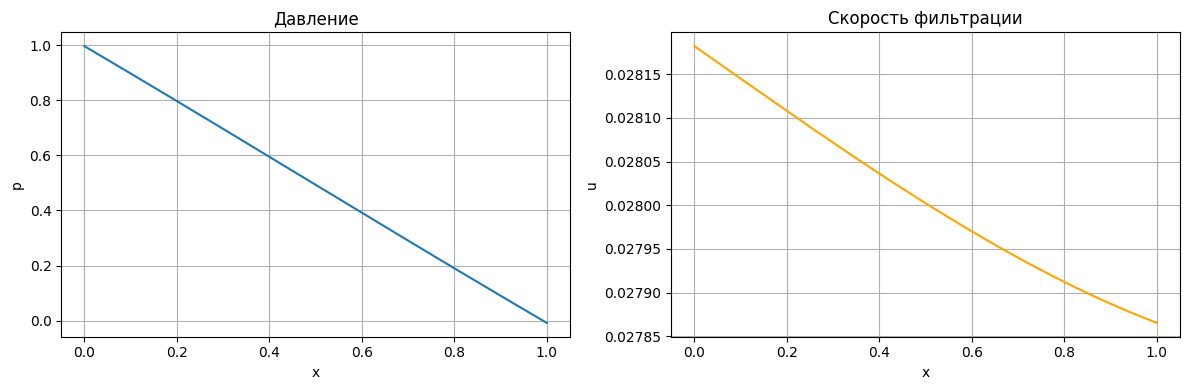

In [6]:
x_plot = np.linspace(0, L, 200)[:, None]
pred = model.predict(x_plot)

p_pred = pred[:, 0]
u_pred = pred[:, 1]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(x_plot, p_pred, label="p(x)")
plt.xlabel("x")
plt.ylabel("p")
plt.title("Давление")
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(x_plot, u_pred, label="u(x)", color="orange")
plt.xlabel("x")
plt.ylabel("u")
plt.title("Скорость фильтрации")
plt.grid()

plt.tight_layout()
plt.show()